# TP — Conversion of sampling rate and STFT (solution)

## 1. Conversion of sampling rate

Goal: convert a signal sampled at $F_s = 48$ kHz into a signal sampled at $F_s' = 32$ kHz.
Since $32/48 = 2/3$, we need a rational conversion with $L = 2$ (upsampling) and $M = 3$ (downsampling).

```mermaid
flowchart LR
    a0(( )) --> a1["↑2"] --> a2["w(n)"] --> a3["↓3"] --> a4(( ))
    style a0 fill:none,stroke:none
    style a4 fill:none,stroke:none
```


In [1]:
import time

import librosa
import librosa.display
import numpy as np
import scipy.signal as ss
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

In [2]:
Fs_in, x = wavfile.read('tp1_conversion-stft-pw/caravan_48khz.wav')
x = x.astype(float) / 2**15          # int16 -> [-1, 1)
L, M = 2, 3
Fs_out = Fs_in * L // M
print(f'Fs_in = {Fs_in} Hz, Fs_out = {Fs_out} Hz, {len(x)} samples ({len(x)/Fs_in:.1f} s)')

Fs_in = 48000 Hz, Fs_out = 32000 Hz, 805733 samples (16.8 s)


In [3]:
def upsample(x, L):
    v = np.zeros(L * len(x))
    v[::L] = x
    return v

def downsample(x, M):
    return x[::M]


# Specification of H(z), derived from L and M (normalized frequencies at L*Fs_in = 96 kHz)
Fs_mid = L * Fs_in
nu_max = min(1 / (2 * L), 1 / (2 * M))    # stop-band edge: Nyquist of the output
nu_a = nu_max                             # 1/6 -> 16 kHz
nu_c = 0.15                               # pass-band edge (transition band 14.4-16 kHz)
gain = L                                  # Inserting zeros divides the amplitude of the signal by L
print(f'intermediate rate: {Fs_mid} Hz')
print(f'pass-band: [0, {nu_c:.4f}] -> [0, {nu_c * Fs_mid / 1e3:.1f}] kHz, gain {gain}')
print(f'stop-band: [{nu_a:.4f}, 0.5] -> [{nu_a * Fs_mid / 1e3:.1f}, {Fs_mid / 2e3:.0f}] kHz, attenuation >= 50 dB')

intermediate rate: 96000 Hz
pass-band: [0, 0.1500] -> [0, 14.4] kHz, gain 2
stop-band: [0.1667, 0.5] -> [16.0, 48] kHz, attenuation >= 50 dB


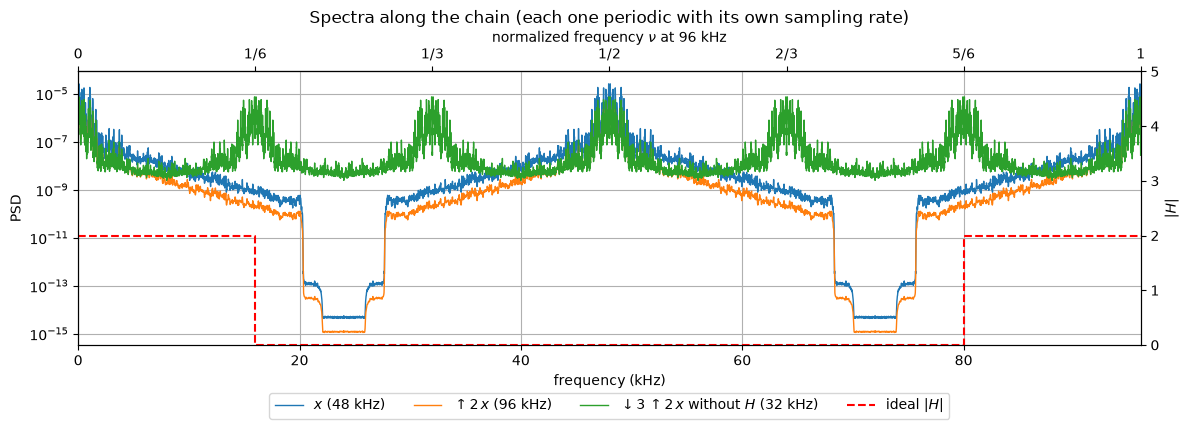

In [4]:
# Spectra along the chain, to see why H is needed
v = upsample(x, L)             # after ↑2 (96 kHz)
y_alias = downsample(v, M)     # ↓3 without filtering (32 kHz)
stages = [(x, Fs_in, r'$x$ (48 kHz)'),
          (v, Fs_mid, r'$\uparrow 2\, x$ (96 kHz)'),
          (y_alias, Fs_out, r'$\downarrow 3\, \uparrow 2\, x$ without $H$ (32 kHz)')]


def periodic_psd(s, fs, f_max, nperseg=4096):
    """Two-sided Welch PSD of s, repeated with period fs over [0, f_max)."""
    f, P = ss.welch(s, fs=fs, nperseg=nperseg, return_onesided=False)
    f = np.mod(f, fs)                        # [-fs/2, fs/2) -> [0, fs)
    order = np.argsort(f)
    f, P = f[order], P[order]
    n_per = int(np.ceil(f_max / fs))
    return np.concatenate([f + k * fs for k in range(n_per)]), np.tile(P, n_per)


fig, ax = plt.subplots(figsize=(12, 4.5))
for s, fs, label in stages:
    f, P = periodic_psd(s, fs, Fs_mid)
    ax.semilogy(f / 1e3, P, label=label, lw=1)
ax.set(xlabel='frequency (kHz)', ylabel='PSD', xlim=(0, Fs_mid / 1e3),
       title='Spectra along the chain (each one periodic with its own sampling rate)')
ax.grid(True)

# second x-axis: normalized frequency at the intermediate rate (96 kHz)
ax_nu = ax.secondary_xaxis('top', functions=(lambda f: f * 1e3 / Fs_mid, lambda nu: nu * Fs_mid / 1e3))
ax_nu.set_xlabel(r'normalized frequency $\nu$ at 96 kHz')
ax_nu.set_xticks(np.arange(0, 1.01, 1/6))
ax_nu.set_xticklabels(['0', '1/6', '1/3', '1/2', '2/3', '5/6', '1'])

# ideal template of H (gain L on |nu| < 1/6, periodic with period 1)
ax_H = ax.twinx()
f_H = np.array([0, nu_a, nu_a, 1 - nu_a, 1 - nu_a, 1]) * Fs_mid / 1e3
ax_H.plot(f_H, [gain, gain, 0, 0, gain, gain], 'r--', label='ideal $|H|$')
ax_H.set(ylim=(0, 2.5 * gain), ylabel='$|H|$')

lines = ax.get_legend_handles_labels()[0] + ax_H.get_legend_handles_labels()[0]
ax.legend(lines, [l.get_label() for l in lines], loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.tight_layout()
plt.show()

How to read the plot (frequencies in Hz, each spectrum drawn over several periods):

- **Blue and orange have the same shape.** Zero insertion does not change the spectrum; it only changes the rate at which it is sampled. At 48 kHz, the copy of the spectrum centred on 48 kHz is just the periodic repetition of $x$. At 96 kHz it lies inside the new band $[0, F_s/2]$ ($\nu = 1/2$): this is the **image** that $H$ has to remove. Orange is also lower, because the power is divided by $L$ and spread over a band twice as wide.
- **Green is periodic with period 32 kHz.** Without $H$, the copies centred on 32 and 64 kHz overlap the useful band: everything above 16 kHz ($\nu = 1/6$) folds back into $[0, 16]$ kHz. That includes the image and the content of $x$ between 16 and 24 kHz. This is **aliasing**.
- **Red (ideal $H$)** keeps only $|\nu| < 1/6$, i.e. $[0, 16]$ kHz and its mirror near 96 kHz, with gain $L$.

### Q2. Filter design (Remez)

The stop-band is given a larger weight than the pass-band: this trades some pass-band ripple for more attenuation.

pass-band: [5.92, 6.12] dB (20 log10 L = 6.02 dB)
stop-band max: -52.45 dB  ->  pass/stop difference = 58.4 dB


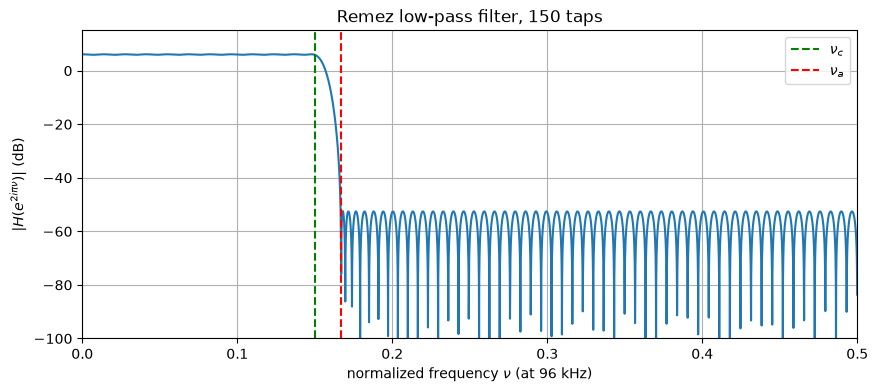

In [56]:
Nh = 150                                     # even length
h = ss.remez(Nh, [0, nu_c, nu_a, 0.5], [gain, 0], weight=[1, 10])

nu, H = ss.freqz(h, worN=8192, fs=1)
H_dB = 20 * np.log10(np.abs(H))
pass_min = H_dB[nu <= nu_c].min()
stop_max = H_dB[nu >= nu_a].max()
print(f'pass-band: [{pass_min:.2f}, {H_dB[nu <= nu_c].max():.2f}] dB (20 log10 L = {20*np.log10(L):.2f} dB)')
print(f'stop-band max: {stop_max:.2f} dB  ->  pass/stop difference = {pass_min - stop_max:.1f} dB')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(nu, H_dB)
ax.axvline(nu_c, color='g', ls='--', label=r'$\nu_c$')
ax.axvline(nu_a, color='r', ls='--', label=r'$\nu_a$')
ax.set(xlabel=r'normalized frequency $\nu$ (at 96 kHz)', ylabel=r'$|H(e^{2i\pi\nu})|$ (dB)',
       title=f'Remez low-pass filter, {Nh} taps', xlim=(0, 0.5), ylim=(-100, 15))
ax.legend(); ax.grid(True)
plt.show()

### Q3. Direct implementation

We apply the chain literally: insert zeros, filter at 96 kHz, keep one sample out of three.

In [6]:
def my_resample(x, h, L=2, M=3):
    return downsample(ss.lfilter(h, 1, upsample(x, L)), M)


y_direct = my_resample(x, h, L, M)
print(f'{len(x)} samples at {Fs_in} Hz -> {len(y_direct)} samples at {Fs_out} Hz')

805733 samples at 48000 Hz -> 537156 samples at 32000 Hz


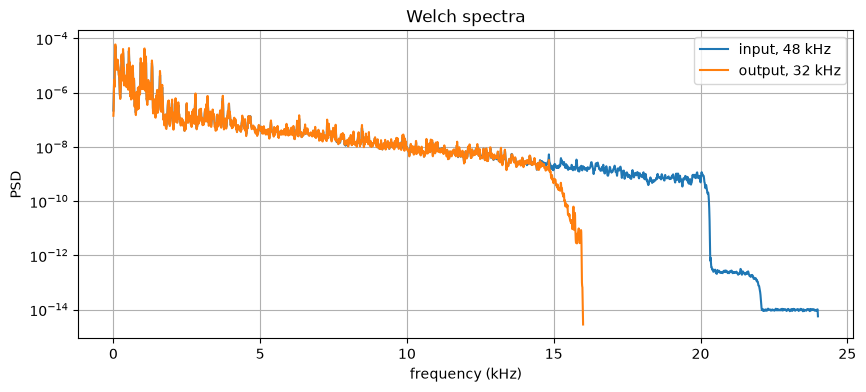

In [7]:
# Check: the output spectrum should be empty above ~14.4 kHz, without aliasing
f_in, P_in = ss.welch(x, Fs_in, nperseg=4096)
f_out, P_out = ss.welch(y_direct, Fs_out, nperseg=4096)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_in / 1e3, P_in, label='input, 48 kHz')
ax.semilogy(f_out / 1e3, P_out, label='output, 32 kHz')
ax.set(xlabel='frequency (kHz)', ylabel='PSD', title='Welch spectra')
ax.legend(); ax.grid(True)
plt.show()

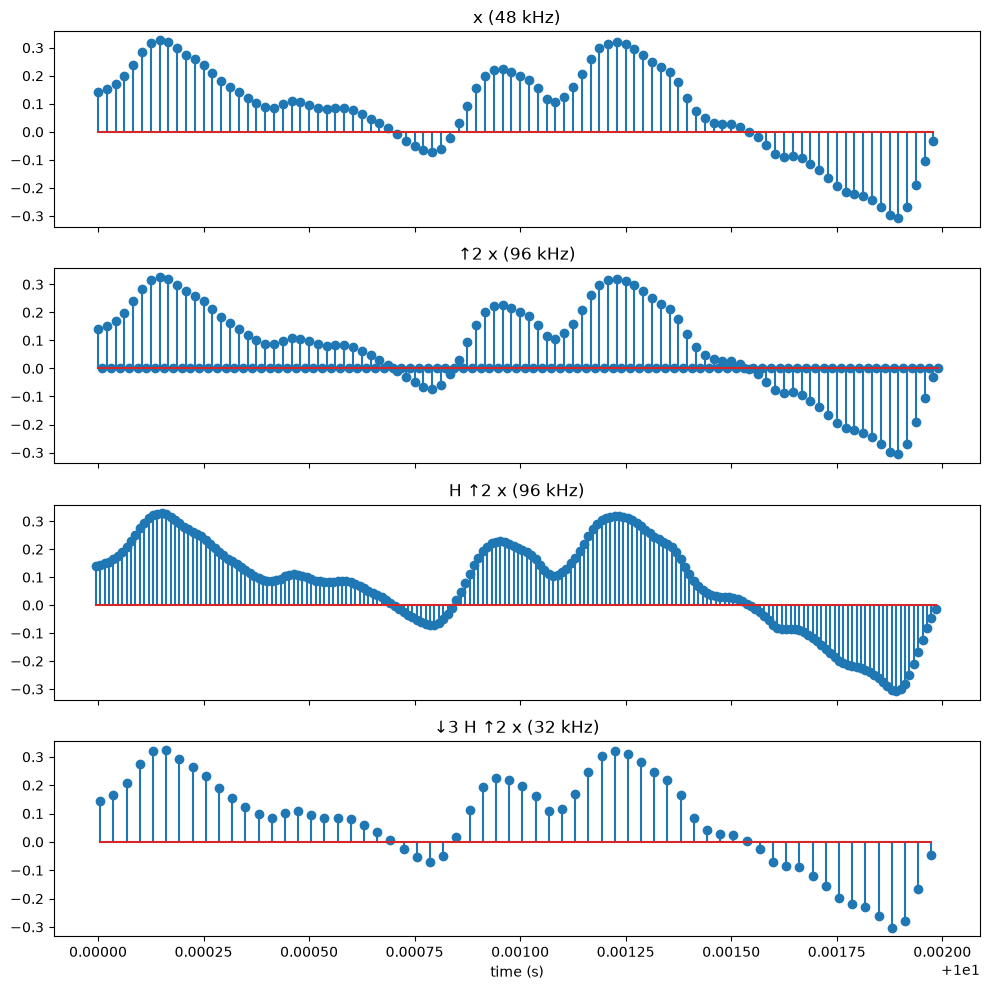

In [8]:
N = 96                      # multiple of M, so the 32 kHz grid lines up
start = 10 * Fs_in          # 2*start is a multiple of M
D = (len(h) - 1) / 2        # group delay of h, in samples at 96 kHz

v = upsample(x, L)
w = ss.lfilter(h, 1, v)
y = downsample(w, M)

s1, n1 = L * start, L * N               # window at 96 kHz
s3, n3 = L * start // M, L * N // M     # window at 32 kHz
d1, d3 = int(D), int(np.ceil(D / M))    # shift the filtered windows by the delay

fig, axarr = plt.subplots(4, 1, figsize=[10, 10], sharex=True)
axarr[0].stem(np.arange(start, start + N) / Fs_in, x[start:start + N])
axarr[1].stem(np.arange(s1, s1 + n1) / Fs_mid, v[s1:s1 + n1])
k = np.arange(s1 + d1, s1 + d1 + n1)
axarr[2].stem((k - D) / Fs_mid, w[k])
m = np.arange(s3 + d3, s3 + d3 + n3)
axarr[3].stem((M * m - D) / Fs_mid, y[m])          # y[m] = w[3m]
for ax, t in zip(axarr, ['x (48 kHz)', '↑2 x (96 kHz)', 'H ↑2 x (96 kHz)', '↓3 H ↑2 x (32 kHz)']):
    ax.set_title(t)
axarr[-1].set_xlabel('time (s)')
plt.tight_layout()

In [9]:
excerpt = 10  # seconds
display(Audio(x[:excerpt * Fs_in], rate=Fs_in))
display(Audio(y_direct[:excerpt * Fs_out], rate=Fs_out))

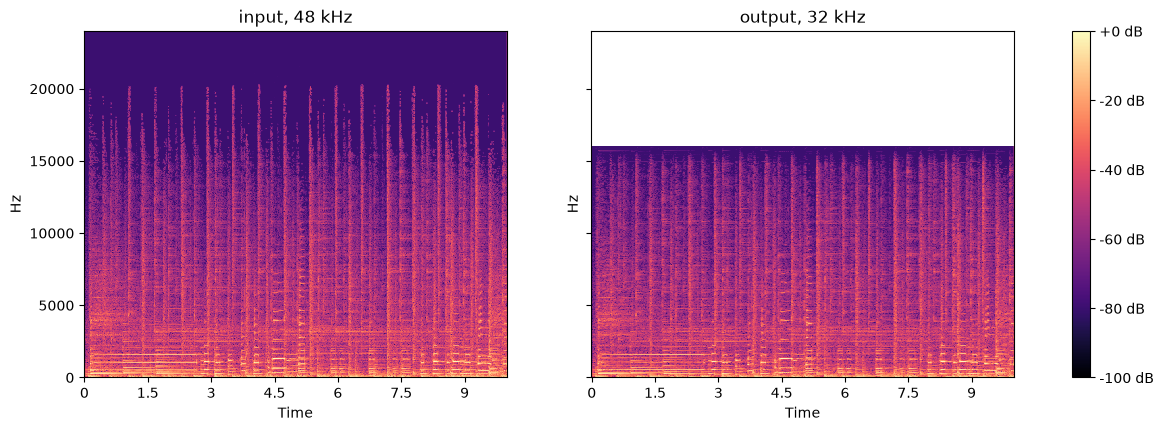

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, (s, fs, title) in zip(axes, [(x, Fs_in, 'input, 48 kHz'), (y_direct, Fs_out, 'output, 32 kHz')]):
    S_dB = librosa.amplitude_to_db(np.abs(librosa.stft(s[:excerpt * fs], n_fft=2048, hop_length=512)), ref=np.max)
    img = librosa.display.specshow(S_dB, sr=fs, hop_length=512, x_axis='time', y_axis='linear', ax=ax, vmin=-100)
    ax.set_title(title)
axes[1].set_ylim(0, Fs_in / 2)
fig.colorbar(img, ax=axes, format='%+2.0f dB')
plt.show()

The direct chain is wasteful: $H$ runs at the highest rate (96 kHz), half of its inputs are zeros, and two thirds of its outputs are discarded by ↓3.

### Q4. Equivalence of Figure 1

```mermaid
flowchart LR
    a0(( )) --> a1["↑2"] --> a2["z<sup>-1</sup>"] --> a3["↓3"] --> a4(( ))
    b0(( )) --> b1["z"] --> b2["↓3"] --> b3["↑2"] --> b4["z<sup>-1</sup>"] --> b5(( ))
    style a0 fill:none,stroke:none
    style a4 fill:none,stroke:none
    style b0 fill:none,stroke:none
    style b5 fill:none,stroke:none
```

Write $z^{-1} = z^{2} \cdot z^{-3}$ and use the noble identities:

1. ↑2 followed by $z^{2} = (z)^2$ is equivalent to $z$ followed by ↑2 (noble identity for the upsampler: $G(z^L)$ after ↑L = $G(z)$ before ↑L);
2. $z^{-3} = (z^{-1})^3$ followed by ↓3 is equivalent to ↓3 followed by $z^{-1}$ (noble identity for the downsampler: $G(z^M)$ before ↓M = $G(z)$ after ↓M);
3. ↑2 and ↓3 commute because $\gcd(2, 3) = 1$.

Hence
$$\uparrow 2 \to z^{-1} \to \downarrow 3 \;=\; \uparrow 2 \to z^{2} \to z^{-3} \to \downarrow 3 \;=\; z \to \uparrow 2 \to \downarrow 3 \to z^{-1} \;=\; z \to \downarrow 3 \to \uparrow 2 \to z^{-1}.$$

The advance $z$ is non-causal, but it only acts on a stored signal, so it is just a one-sample shift: $(z\,x)(n) = x(n+1)$.

In [11]:
def delay(x):      # z^{-1}
    return np.concatenate([[0], x[:-1]])

def advance(x):    # z
    return np.concatenate([x[1:], [0]])

r = np.random.randn(3000)
top = downsample(delay(upsample(r, 2)), 3)
bottom = delay(upsample(downsample(advance(r), 3), 2))
n = min(len(top), len(bottom))
print('max |top - bottom| =', np.max(np.abs(top[:n] - bottom[:n])))

max |top - bottom| = 0.0


### Q5. Efficient implementation with polyphase decompositions

We follow sections 5 and 6 of Chapter 3 of the course notes, in four steps:

| Step | Idea | Course reference |
|---|---|---|
| 5a | Split $h$ into polyphase components (type I and type II) | §5, Fig. 3.9–3.11 |
| 5b | Efficient **downsampling** with type I components | §6.1, Fig. 3.12 |
| 5c | Efficient **upsampling** with type II components | §6.2, Fig. 3.13 |
| 5d | Combine both for the 2/3 conversion | Q4 + noble identities |

Each step is checked numerically against the direct implementation.

#### 5a. Polyphase components (§5)

The polyphase components of $h$ at order $M$ are obtained by **decimating time-shifted versions of $h$** (Fig. 3.9). There are two ways to index them:

- **Type I** (§5.2): $\displaystyle H(z) = \sum_{m=0}^{M-1} E_m(z^M)\, z^{-m}$, with $e_m(n) = h(nM + m)$.
  $e_0$ takes the taps $h(0), h(M), h(2M), \dots$, $e_1$ takes $h(1), h(M+1), \dots$, and so on.
- **Type II** (§5.3): $\displaystyle H(z) = \sum_{l=0}^{L-1} R_l(z^L)\, z^{-(L-1-l)}$, with $r_l(n) = h(nL + L-1-l)$.
  Same components, numbered in reverse order: $R_l = E_{L-1-l}$.

Each $E_m(z)$ is an ordinary filter with about $N_h/M$ taps. Writing it as $E_m(z^M)$ spreads its taps back out with $M-1$ zeros between them, and the delay $z^{-m}$ puts them back at their original positions in $h$.

In [12]:
def polyphase_type1(h, M):
    """e_m(n) = h(nM + m), m = 0..M-1"""
    return [h[m::M] for m in range(M)]


def polyphase_type2(h, L):
    """r_l(n) = h(nL + L-1-l), l = 0..L-1"""
    return [h[L - 1 - l::L] for l in range(L)]


def delay_by(x, d):
    """z^{-d}: delay by d samples, keeping the length."""
    return np.concatenate([np.zeros(d), x[:len(x) - d]]) if d > 0 else x.copy()


# Check the definitions: H(z) = sum_m E_m(z^M) z^{-m} rebuilds h
for M_test in [2, 3]:
    e = polyphase_type1(h, M_test)
    h_rebuilt = sum(delay_by(upsample(e[m], M_test)[:len(h)], m) for m in range(M_test))
    print(f'type I,  M = {M_test}: max |h - sum_m E_m(z^M) z^-m| = {np.max(np.abs(h - h_rebuilt)):.1e}')

r = polyphase_type2(h, 2)
h_rebuilt = sum(delay_by(upsample(r[l], 2)[:len(h)], 2 - 1 - l) for l in range(2))
print(f'type II, L = 2: max |h - sum_l R_l(z^L) z^-(L-1-l)| = {np.max(np.abs(h - h_rebuilt)):.1e}')

type I,  M = 2: max |h - sum_m E_m(z^M) z^-m| = 0.0e+00
type I,  M = 3: max |h - sum_m E_m(z^M) z^-m| = 0.0e+00
type II, L = 2: max |h - sum_l R_l(z^L) z^-(L-1-l)| = 0.0e+00


#### 5b. Efficient structure for downsampling (§6.1)

Direct downsampling (Fig. 3.12a) filters at the high rate and then throws away $M-1$ samples out of $M$:

```mermaid
flowchart LR
    x["x(n)"] --> H["H(z)"] --> D["↓M"] --> y["y(m)"]
```

Substitute the type I decomposition $H(z) = \sum_m z^{-m} E_m(z^M)$. In each branch, $E_m(z^M)$ followed by ↓M is equivalent to ↓M followed by $E_m(z)$ (noble identity, Fig. 3.6 top). We get Fig. 3.12b:

```mermaid
flowchart LR
    x["x(n)"] --> D0["↓M"] --> E0["E₀(z)"] --> S(("+"))
    x --> Z1["z⁻¹"] --> D1["↓M"] --> E1["E₁(z)"] --> S
    x --> Z2["z⁻²"] --> D2["↓M"] --> E2["E₂(z)"] --> S
    S --> y["y(m)"]
```

In words: split the input into its $M$ phases $x(kM - m)$, filter each phase with the matching short filter $E_m$, and add. Every filter now runs at the **low** rate $F_s/M$ and has about $N_h/M$ taps, and nothing that is computed gets thrown away. Each polyphase filter is $M^2$ times cheaper than $H$ running at $F_s$ (the factor given in the course); with $M$ branches, the total cost is divided by $M$.

In [14]:
def downsample_efficient(x, h, M):
    """y = ↓M (H x), computed with type I polyphase components (Fig. 3.12b)."""
    e = polyphase_type1(h, M)
    y = np.zeros(int(np.ceil(len(x) / M)))
    for m in range(M):
        x_m = downsample(delay_by(x, m), M)   # ↓M (z^{-m} x): the m-th phase of x
        y += ss.lfilter(e[m], 1, x_m)        # E_m(z), at the low rate
    return y


x_test = np.random.randn(10_000)
for M_test in [2, 3]:
    y_ref = downsample(ss.lfilter(h, 1, x_test), M_test)
    y_eff = downsample_efficient(x_test, h, M_test)
    print(f'M = {M_test}: max |direct - efficient| = {np.max(np.abs(y_ref - y_eff)):.1e}')

M = 2: max |direct - efficient| = 1.1e-15
M = 3: max |direct - efficient| = 1.3e-15


#### 5c. Efficient structure for upsampling (§6.2)

Direct upsampling (Fig. 3.13a) inserts zeros and then filters at the high rate, so half the multiplications (for $L = 2$) are by zero:

```mermaid
flowchart LR
    x["x(n)"] --> U["↑L"] --> H["H(z)"] --> y["y(m)"]
```

Substitute the type II decomposition $H(z) = \sum_l R_l(z^L)\, z^{-(L-1-l)}$. In each branch, ↑L followed by $R_l(z^L)$ is equivalent to $R_l(z)$ followed by ↑L (noble identity, Fig. 3.6 bottom). We get Fig. 3.13b for $L = 2$:

```mermaid
flowchart LR
    x["x(n)"] --> R0["R₀(z)"] --> U0["↑2"] --> Z["z⁻¹"] --> S(("+"))
    x --> R1["R₁(z)"] --> U1["↑2"] --> S
    S --> y["y(m)"]
```

The filters $R_l$ run at the **low** rate $F_s$ and never see the inserted zeros. The ↑2 and the delay $z^{-1}$ just **interleave** the outputs of the two branches: $y(2k) = (R_1 x)(k)$ and $y(2k+1) = (R_0 x)(k)$.

In [15]:
def upsample_efficient(x, h, L):
    """y = H (↑L x), computed with type II polyphase components (Fig. 3.13b)."""
    r = polyphase_type2(h, L)
    y = np.zeros(L * len(x))
    for l in range(L):
        y += delay_by(upsample(ss.lfilter(r[l], 1, x), L), L - 1 - l)   # R_l(z), ↑L, z^{-(L-1-l)}
    return y


for L_test in [2, 3]:
    y_ref = ss.lfilter(h, 1, upsample(x_test, L_test))
    y_eff = upsample_efficient(x_test, h, L_test)
    print(f'L = {L_test}: max |direct - efficient| = {np.max(np.abs(y_ref - y_eff)):.1e}')

L = 2: max |direct - efficient| = 8.9e-16
L = 3: max |direct - efficient| = 8.9e-16


```mermaid
flowchart LR
    x["x(n)<br>48 kHz"]

    %% branch 0: odd taps r0(n) = h(2n+1), needs the advance z (Figure 1)
    x --> A["z"]
    A --> D00["↓3"] --> R00["R₀,₀(z)"] --> S0(("+"))
    A --> Z01["z⁻¹"] --> D01["↓3"] --> R01["R₀,₁(z)"] --> S0
    A --> Z02["z⁻²"] --> D02["↓3"] --> R02["R₀,₂(z)"] --> S0
    S0 -- "u₀ @ 16 kHz" --> U0["↑2"] --> ZD["z⁻¹"] --> S(("+"))

    %% branch 1: even taps r1(n) = h(2n)
    x --> D10["↓3"] --> R10["R₁,₀(z)"] --> S1(("+"))
    x --> Z11["z⁻¹"] --> D11["↓3"] --> R11["R₁,₁(z)"] --> S1
    x --> Z12["z⁻²"] --> D12["↓3"] --> R12["R₁,₂(z)"] --> S1
    S1 -- "u₁ @ 16 kHz" --> U1["↑2"] --> S

    S --> y["y(m)<br>32 kHz"]
```

```mermaid
flowchart LR
    x["x(n)<br>48 kHz"]
    x --> A["z"] --> P0["↓3"]
    x --> P1["↓3"]
    x --> Z1["z⁻¹"] --> P2["↓3"]
    x --> Z2["z⁻²"] --> P3["↓3"]

    P0 --> R00["R₀,₀(z)"] --> S0(("+"))
    P1 --> R01["R₀,₁(z)"] --> S0
    P2 --> R02["R₀,₂(z)"] --> S0
    S0 -- "u₀ @ 16 kHz" --> U0["↑2"] --> ZD["z⁻¹"] --> S(("+"))

    P1 --> R10["R₁,₀(z)"] --> S1(("+"))
    P2 --> R11["R₁,₁(z)"] --> S1
    P3 --> R12["R₁,₂(z)"] --> S1
    S1 -- "u₁ @ 16 kHz" --> U1["↑2"] --> S

    S --> y["y(m)<br>32 kHz"]
```


```mermaid
flowchart LR
    x["x(n)<br>48 kHz"]

    %% branch 0: odd taps r0(n) = h(2n+1), needs the advance z (Figure 1)
    x --> Z00["z"] --> D00["↓3"] --> R00["R₀,₀(z)"] --> S0(("+"))
    x --> D01["↓3"] --> R01["R₀,₁(z)"] --> S0
    x --> Z02["z⁻¹"] --> D02["↓3"] --> R02["R₀,₂(z)"] --> S0
    S0 -- "u₀ @ 16 kHz" --> U0["↑2"] --> ZD["z⁻¹"] --> S(("+"))

    %% branch 1: even taps r1(n) = h(2n)
    x --> D10["↓3"] --> R10["R₁,₀(z)"] --> S1(("+"))
    x --> Z11["z⁻¹"] --> D11["↓3"] --> R11["R₁,₁(z)"] --> S1
    x --> Z12["z⁻²"] --> D12["↓3"] --> R12["R₁,₂(z)"] --> S1
    S1 -- "u₁ @ 16 kHz" --> U1["↑2"] --> S

    S --> y["y(m)<br>32 kHz"]
```

#### 5d. Combining both for the 2/3 conversion

**Step 1: efficient upsampling.** Replace ↑2 → $H$ by the structure of §6.2. The ↓3 is still at the output:

```mermaid
flowchart LR
    x["x(n)<br>48 kHz"] --> R0["R₀(z)"] --> U0["↑2"] --> Z["z⁻¹"] --> S(("+"))
    x --> R1["R₁(z)"] --> U1["↑2"] --> S
    S -- "96 kHz" --> D["↓3"] --> y["y(n)<br>32 kHz"]
```

The filters now run at 48 kHz instead of 96 kHz, but we still compute 96 kHz samples and discard two thirds of them.

**Step 2: move ↓3 into the branches.** ↓3 is linear, so it can be applied to each branch before the sum:
- branch $R_1$: ↑2 → ↓3 = ↓3 → ↑2, because 2 and 3 are coprime (Fig. 3.8);
- branch $R_0$: ↑2 → $z^{-1}$ → ↓3 = $z$ → ↓3 → ↑2 → $z^{-1}$, by the equivalence of Q4 (Figure 1 of the TP).

```mermaid
flowchart LR
    x["x(n)<br>48 kHz"] --> A["z"] --> R0["R₀(z)"] --> D0["↓3"] --> U0["↑2"] --> Z["z⁻¹"] --> S(("+"))
    x --> R1["R₁(z)"] --> D1["↓3"] --> U1["↑2"] --> S
    S --> y["y(n)<br>32 kHz"]
```

($z$ and $R_0(z)$ commute, since both are LTI filters.) The final ↑2, $z^{-1}$ and + simply interleave the two branches, which are at 16 kHz: $y(2k) = u_1(k)$ and $y(2k+1) = u_0(k)$, with $u_1 = \downarrow 3\,(R_1 x)$ and $u_0 = \downarrow 3\,(R_0\, z x)$.

**Step 3: efficient downsampling in each branch.** Each branch is now "filter $R_l$, then ↓3", which is exactly the situation of §6.1. We replace it by the type I structure with $M = 3$. Each $R_l$ (75 taps) is split into 3 components of 25 taps, which run at **16 kHz**.

**Cost** (multiplications per second, $N_h$ = 150 taps):

| | filters | taps each | rate | multiplications / s |
|---|---|---|---|---|
| direct | $H$ | $N_h$ | 96 kHz | $96\,000\, N_h$ |
| step 1 | $R_0, R_1$ | $N_h/2$ | 48 kHz | $48\,000\, N_h$ |
| step 3 | $2 \times 3$ components | $N_h/6$ | 16 kHz | $16\,000\, N_h$ |

The step-2 structure costs the same as step 1 if $R_l x$ is computed at every 48 kHz sample and then decimated; the saving comes in step 3, where only the samples that are kept get computed. Overall gain: $L \times M = 6$.

In [16]:
def resample_step1(x, h):
    """Step 1: efficient upsampling (§6.2), then ↓3."""
    return downsample(upsample_efficient(x, h, 2), 3)


def interleave(u_even, u_odd):
    """↑2 u_even + z^{-1} ↑2 u_odd"""
    n = min(len(u_even), len(u_odd))
    y = np.zeros(2 * n)
    y[0::2], y[1::2] = u_even[:n], u_odd[:n]
    return y


def resample_step2(x, h):
    """Step 2: ↓3 moved into the branches (filters still at 48 kHz)."""
    r0, r1 = polyphase_type2(h, 2)
    u1 = downsample(ss.lfilter(r1, 1, x), 3)            # ↓3 (R_1 x)
    u0 = downsample(ss.lfilter(r0, 1, advance(x)), 3)   # ↓3 (R_0 z x)
    return interleave(u1, u0)


def resample_step3(x, h):
    """Step 3: each "R_l then ↓3" replaced by the type I structure (§6.1), filters at 16 kHz."""
    r0, r1 = polyphase_type2(h, 2)
    u1 = downsample_efficient(x, r1, 3)                 # ↓3 (R_1 x)
    u0 = downsample_efficient(advance(x), r0, 3)        # ↓3 (R_0 z x)
    return interleave(u1, u0)


implementations = {'direct': my_resample, 'step 1': resample_step1,
                   'step 2': resample_step2, 'step 3': resample_step3}
outputs = {name: f(x, h) for name, f in implementations.items()}
y_poly = outputs['step 3']
for name, y_k in outputs.items():
    n = min(len(y_direct), len(y_k))
    print(f'{name:7s}: {len(y_k)} samples, max |y_direct - y| = {np.max(np.abs(y_direct[:n] - y_k[:n])):.1e}')

direct : 537156 samples, max |y_direct - y| = 0.0e+00
step 1 : 537156 samples, max |y_direct - y| = 2.2e-16
step 2 : 537156 samples, max |y_direct - y| = 2.2e-16
step 3 : 537156 samples, max |y_direct - y| = 2.2e-16


### Q6. Comparison of the implementations

In [17]:
def best_time(f, *args, repeat=5):
    times = []
    for _ in range(repeat):
        t0 = time.time()
        f(*args)
        times.append(time.time() - t0)
    return min(times)


t_direct = best_time(my_resample, x, h)
for name, f in implementations.items():
    t = best_time(f, x, h)
    print(f'{name:7s}: {1e3 * t:6.1f} ms   speed-up {t_direct / t:.1f}')
print(f'theoretical speed-up of step 3: L*M = {L * M}')

direct :   24.0 ms   speed-up 1.0
step 1 :   15.2 ms   speed-up 1.6
step 2 :   13.8 ms   speed-up 1.8


step 3 :   11.4 ms   speed-up 2.1
theoretical speed-up of step 3: L*M = 6


All the implementations give the same output up to rounding errors. The measured speed-ups are below the theoretical factors because `lfilter` is compiled code: for such short filters, the fixed overheads (6 calls instead of 1, array copies for the phases and the interleaving) are not negligible compared with the multiplications themselves. The gap shrinks as the filter gets longer.

## 2. STFT audio equalization

We start from the notebook template (`template-TP-conversion-STFT.ipynb`). Its analysis loop is kept, with three fixes: frames start at `u * R` (the `+ 1` is a leftover from Matlab's 1-based indexing), `R` is an integer, and the window is the one required by each question.

### 2.1 STFT analysis

#### Q1. DFT of the Hann window

The Hann window of length $N_w$ is a sum of three shifted complex exponentials:
$$w(n) = \tfrac12 - \tfrac12 \cos\!\left(\tfrac{2\pi n}{N_w}\right) = \tfrac12 - \tfrac14 e^{2i\pi n/N_w} - \tfrac14 e^{-2i\pi n/N_w}, \qquad 0 \le n < N_w .$$
Its DTFT is therefore the sum of three Dirichlet kernels (the DTFT of the rectangular window, with zeros at multiples of $1/N_w$), centred on $0$ and $\pm 1/N_w$. The side kernels cancel the first zeros $\pm 1/N_w$ of the central one, so the first zeros of $\hat w$ are at $\pm 2/N_w$:

$$\text{main-lobe width} = \frac{4}{N_w} \quad\text{(twice that of the rectangular window, } 2/N_w\text{)}.$$

We plot $\hat w(k/M)$ with $M \gg N_w$ (zero-padding) to sample the DTFT finely.

Nw = 16: main-lobe width = 0.2666,  4/Nw = 0.2500
Nw = 32: main-lobe width = 0.1289,  4/Nw = 0.1250
Nw = 64: main-lobe width = 0.0635,  4/Nw = 0.0625


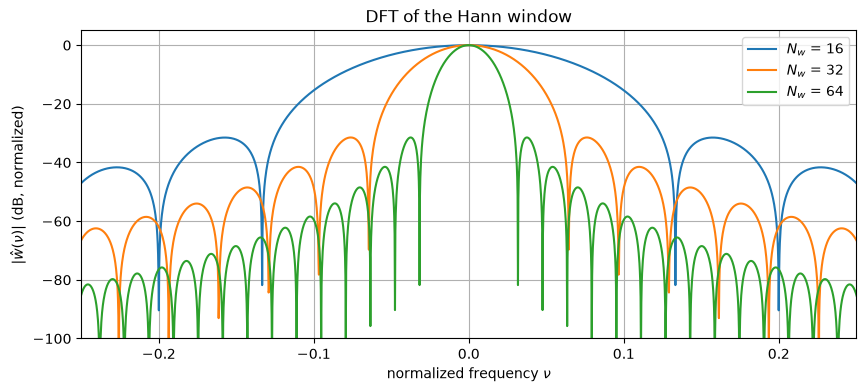

In [18]:
M_plot = 4096                       # DFT order, M >= Nw (zero-padding)
fig, ax = plt.subplots(figsize=(10, 4))
for Nw_q1 in [16, 32, 64]:
    w_q1 = np.hanning(Nw_q1)
    W = np.fft.fftshift(np.fft.fft(w_q1, M_plot))
    nu = np.fft.fftshift(np.fft.fftfreq(M_plot))
    ax.plot(nu, 20 * np.log10(np.abs(W) / np.abs(W).max() + 1e-12), label=f'$N_w$ = {Nw_q1}')
    # measured main lobe: first minimum of |W| for nu > 0
    W_pos = np.abs(W[M_plot // 2:])
    first_zero = np.argmax(np.diff(W_pos) > 0) / M_plot
    print(f'Nw = {Nw_q1:2d}: main-lobe width = {2 * first_zero:.4f},  4/Nw = {4 / Nw_q1:.4f}')
ax.set(xlabel=r'normalized frequency $\nu$', ylabel=r'$|\hat w(\nu)|$ (dB, normalized)',
       xlim=(-0.25, 0.25), ylim=(-100, 5), title='DFT of the Hann window')
ax.legend(); ax.grid(True)
plt.show()

The measured widths are slightly larger than $4/N_w$ because `np.hanning` is the *symmetric* Hann window: its end samples are zero, so its effective length is $N_w - 1$ and the first zeros are at $\pm 2/(N_w-1)$. The side lobes decay quickly (first one at $-31$ dB), which is why the Hann window is a good default for spectral analysis.

#### Q2. Low-pass convention: STFT as filtering

At fixed $\lambda$, with $w$ symmetric ($w(-n) = w(n)$):
$$W_x(\lambda, b) = \sum_{n} \underbrace{x(n)\, e^{-2i\pi\lambda n}}_{x_\lambda(n)}\; w(b - n) = (x_\lambda * w)(b).$$

The STFT at frequency $\lambda$ is obtained in two steps:
1. **modulation**: $x_\lambda(n) = x(n) e^{-2i\pi\lambda n}$ shifts the spectrum of $x$ by $-\lambda$, so the frequency $\lambda$ is moved to $0$;
2. **filtering by $w$**, which is a **low-pass** filter (its frequency response is $\hat w$, concentrated in the main lobe $|\nu| < 2/N_w$).

$W_x(\lambda, \cdot)$ therefore contains the components of $x$ in the band $[\lambda - 2/N_w,\, \lambda + 2/N_w]$, **shifted to baseband**. This is why it is called the low-pass convention.

As a FIR filter, $w$ is real and symmetric, so it has linear phase:
- $N_w$ **odd** → **type 1** (symmetric, odd length): no forced zero;
- $N_w$ **even** → **type 2** (symmetric, even length): forced zero at $\nu = 1/2$. This is harmless here since $w$ is a low-pass filter.

(Types 3 and 4 are antisymmetric, which does not apply to a window.)

#### Q3. Band-pass convention

With $m = n + b$:
$$\tilde X(\lambda, b) = \sum_{m} x(m)\, w(m - b)\, e^{-2i\pi\lambda (m - b)} = e^{2i\pi\lambda b}\, W_x(\lambda, b).$$

It is the same quantity, remodulated to frequency $\lambda$. Written as a convolution:
$$\tilde X(\lambda, b) = \sum_m x(m)\, g_\lambda(b - m) = (x * g_\lambda)(b), \qquad g_\lambda(n) = w(-n)\, e^{2i\pi\lambda n}.$$
$g_\lambda$ is the window modulated to frequency $\lambda$, i.e. a **band-pass** filter centred on $\lambda$: $\tilde X(\lambda, \cdot)$ is $x$ filtered around $\lambda$, **without** being shifted to baseband.

The template computes `fft(x[u*R : u*R + Nw] * w, M)`, i.e. $\sum_n x(n + uR)\, w(n)\, e^{-2i\pi kn/M}$: this is the **band-pass convention**, eq. (3) of the handout.

#### Q4. One channel: $x_k(u) = \tilde X(k, u)$ with $M = 32$, $R = 1$, $k = 3$

We use the template's analysis loop, written as a function. With $R = 1$ there is one frame per sample, so we work on a 5 s excerpt.

In [19]:
def stft(x, w, R, M):
    # Band-pass convention STFT (template loop): X[k, u] = sum_n x(n + uR) w(n) e^{-2i pi kn/M}.
    Nw = len(w)
    Nt = (len(x) - Nw) // R + 1                     # number of frames
    X = np.zeros((M, Nt), dtype=complex)
    for u in range(Nt):
        X[:, u] = np.fft.fft(x[u * R:u * R + Nw] * w, M)
    return X


Nw4, M4, R4, k = 32, 32, 1, 3
w4 = np.hanning(Nw4)
x_ex = x[:5 * Fs_in]
xk = stft(x_ex, w4, R4, M4)[k]

print(f'x_k is complex: {np.iscomplexobj(xk)},  '
      f'energy of Im(x_k) / energy of x_k = {np.sum(xk.imag**2) / np.sum(np.abs(xk)**2):.2f}')
print(f'channel centre: k/M = {k / M4:.4f} -> {k / M4 * Fs_in / 1e3:.2f} kHz, '
      f'bandwidth (main lobe) 4/Nw = {4 / Nw4:.3f} -> {4 / Nw4 * Fs_in / 1e3:.1f} kHz')

x_k is complex: True,  energy of Im(x_k) / energy of x_k = 0.51
channel centre: k/M = 0.0938 -> 4.50 kHz, bandwidth (main lobe) 4/Nw = 0.125 -> 6.0 kHz


$x_k$ is **complex**: $g_k(n) = w(-n)\, e^{2i\pi kn/M}$ has complex coefficients, and its frequency response $\hat w(\nu - k/M)$ is not Hermitian (it selects $+k/M$ but not $-k/M$), so the output of a real signal is complex. It is the *analytic* version of the band-pass signal around $k/M$: its real and imaginary parts carry the same energy.

**Check with `lfilter`.** $g_k$ has support $[-(N_w-1), 0]$, so it is anti-causal. We filter with the causal version $g_k(n - (N_w-1)) = w(N_w-1-n)\, e^{2i\pi k (n - N_w + 1)/M}$, and compensate the delay of $N_w - 1$ samples.

max |x_k - (g_k * x)| = 1.8e-15


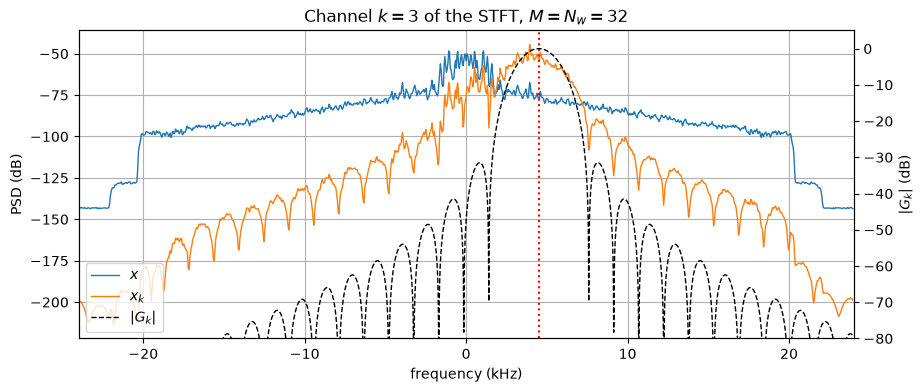

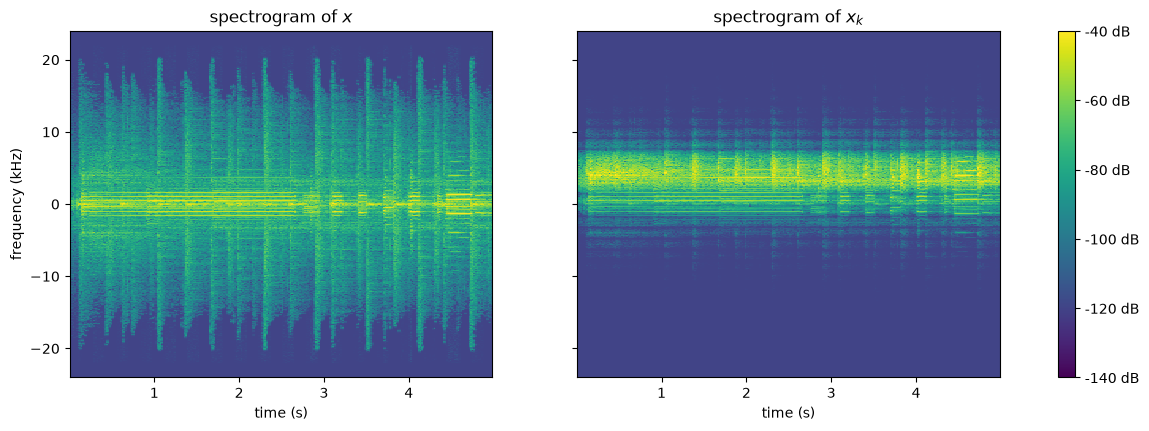

In [20]:
n = np.arange(Nw4)
g_k = w4[::-1] * np.exp(2j * np.pi * k * (n - (Nw4 - 1)) / M4)     # causal version of g_k
xk_filt = ss.lfilter(g_k, 1, x_ex)[Nw4 - 1:]                       # undo the delay Nw - 1
print(f'max |x_k - (g_k * x)| = {np.max(np.abs(xk - xk_filt)):.1e}')

# frequency response of g_k and spectra of x and x_k (two-sided, x_k is complex)
nu_g, G = ss.freqz(g_k, worN=4096, whole=True, fs=Fs_in)
nu_g = np.where(nu_g >= Fs_in / 2, nu_g - Fs_in, nu_g)
f_x, P_x = ss.welch(x_ex, Fs_in, nperseg=1024, return_onesided=False)
f_k, P_k = ss.welch(xk, Fs_in, nperseg=1024, return_onesided=False)

fig, ax = plt.subplots(figsize=(10, 4))
o = np.argsort(f_x)
ax.plot(f_x[o] / 1e3, 10 * np.log10(P_x[o]), label='$x$', lw=1)
ax.plot(f_k[o] / 1e3, 10 * np.log10(P_k[o]), label='$x_k$', lw=1)
ax.set(xlabel='frequency (kHz)', ylabel='PSD (dB)', xlim=(-Fs_in / 2e3, Fs_in / 2e3),
       title=rf'Channel $k = {k}$ of the STFT, $M = N_w = {Nw4}$')
ax_g = ax.twinx()
o = np.argsort(nu_g)
ax_g.plot(nu_g[o] / 1e3, 20 * np.log10(np.abs(G[o]) / np.abs(G).max() + 1e-12), 'k--', lw=1, label='$|G_k|$')
ax_g.set(ylabel='$|G_k|$ (dB)', ylim=(-80, 5))
ax.axvline(k / M4 * Fs_in / 1e3, color='r', ls=':')
lines = ax.get_legend_handles_labels()[0] + ax_g.get_legend_handles_labels()[0]
ax.legend(lines, [l.get_label() for l in lines], loc='lower left'); ax.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, (s, title) in zip(axes, [(x_ex, '$x$'), (xk, '$x_k$')]):
    f, t, S = ss.spectrogram(s, Fs_in, nperseg=1024, return_onesided=False)
    img = ax.pcolormesh(t, np.fft.fftshift(f) / 1e3, 10 * np.log10(np.fft.fftshift(S, axes=0) + 1e-12),
                        vmin=-140, vmax=-40, shading='auto')
    ax.set(title=f'spectrogram of {title}', xlabel='time (s)')
axes[0].set_ylabel('frequency (kHz)')
fig.colorbar(img, ax=axes, format='%+2.0f dB')
plt.show()

`lfilter` gives exactly the same signal, and the spectrogram of $x_k$ only keeps the band around $+k F_s/M = 4.5$ kHz (main lobe $\pm 3$ kHz), on the positive frequencies only. $\mathrm{Re}(x_k) = \tfrac12 (x_k + \bar x_k)$ is real, and contains that band and its mirror image at $-4.5$ kHz: it is $x$ through a real band-pass filter. It sounds like a thin, "telephone" version of the excerpt, without bass or treble.

In [21]:
display(Audio(x_ex, rate=Fs_in))
display(Audio(np.real(xk), rate=Fs_in))

### 2.2 Reconstruction

#### Q5. Perfect reconstruction condition

Since $N_w \le M$, the inverse DFT of order $M$ of the frame $u$ gives back the windowed frame, without time aliasing:
$$\mathrm{DFT}^{-1}[\tilde X(\cdot, u)](n) = x(n + uR)\, w(n), \qquad 0 \le n < M,$$
then $y_s(u, n) = x(n + uR)\, w(n)\, w_s(n)$ (with $w_s$ zero outside $[0, N_w - 1]$). The overlap-add gives
$$y(n) = \sum_u y_s(u, n - uR) = \sum_u x(n)\, w(n - uR)\, w_s(n - uR) = x(n)\, f(n).$$
So $f(n) = \sum_u w(n - uR)\, w_s(n - uR) = 1$ for all $n$ is sufficient for $y = x$.

We take $w = w_s = h$, so the product window is $w_p = h^2$, and a 75% overlap: $R = N_w/4$. Expanding the square of the (periodic) Hann window,
$$\text{hann}^2(n) = \tfrac38 - \tfrac12 \cos\!\left(\tfrac{2\pi n}{N_w}\right) + \tfrac18 \cos\!\left(\tfrac{4\pi n}{N_w}\right).$$
With $N_w/R = 4$ shifted copies, the two cosines (1 and 2 periods per window) sum to zero, and the constant sums to $4 \times \tfrac38 = \tfrac32$. The correct normalization is therefore
$$h(n) = \sqrt{\tfrac23}\;\text{hann}(n).$$

We check this with the template's `ola` function. The window must be the **periodic** Hann (`scipy.signal.get_window('hann', Nw)`): the symmetric one (`np.hanning`) has period $N_w - 1$, and the cancellation is only approximate.

symmetric Hann (np.hanning) : f(n) in [0.997954, 0.998131]
periodic Hann               : f(n) in [1.000000, 1.000000]


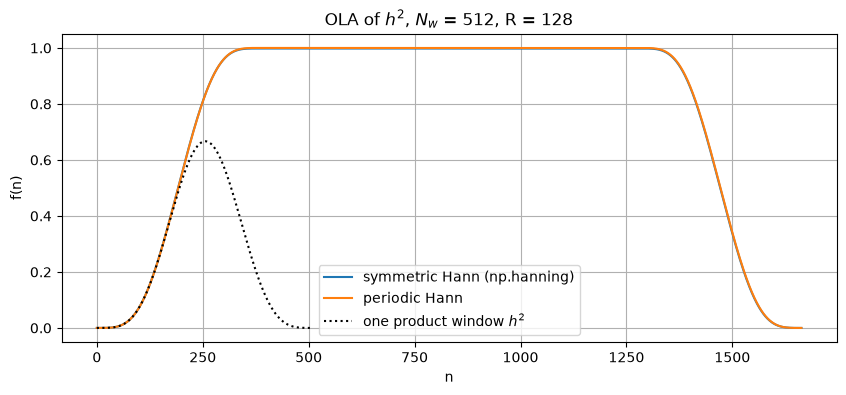

In [22]:
def ola(w, hop, Nb=10):
    # Overlap-add of Nb copies of the window w, shifted by hop (template function).
    N = len(w)
    output = np.zeros((Nb - 1) * hop + N)
    for k in range(Nb):
        output[k * hop:k * hop + N] += w
    return output


Nw = 512
R = Nw // 4                                             # 75% overlap
h_hann = np.sqrt(2 / 3) * ss.get_window('hann', Nw)     # periodic Hann, normalized

fig, ax = plt.subplots(figsize=(10, 4))
for win, label in [(np.sqrt(2 / 3) * np.hanning(Nw), 'symmetric Hann (np.hanning)'),
                   (h_hann, 'periodic Hann')]:
    f_ola = ola(win**2, R)
    steady = f_ola[Nw:-Nw]                               # fully overlapped region
    print(f'{label:28s}: f(n) in [{steady.min():.6f}, {steady.max():.6f}]')
    ax.plot(f_ola, label=label)
ax.plot(ola(h_hann**2, R, Nb=1), 'k:', label='one product window $h^2$')
ax.set(xlabel='n', ylabel='f(n)', title=f'OLA of $h^2$, $N_w$ = {Nw}, R = {R}')
ax.legend(); ax.grid(True)
plt.show()

$f(n) = 1$ in the steady-state region (only the first and last $N_w - R$ samples are covered by fewer than 4 frames).

#### Q6. Overlap-add resynthesis

The synthesis loop mirrors the analysis loop: inverse DFT of each frame, truncation to $N_w$ samples, multiplication by $w_s$, and overlap-add at position $uR$.

6291 frames, max |x - y| on the fully covered samples = 3.3e-16


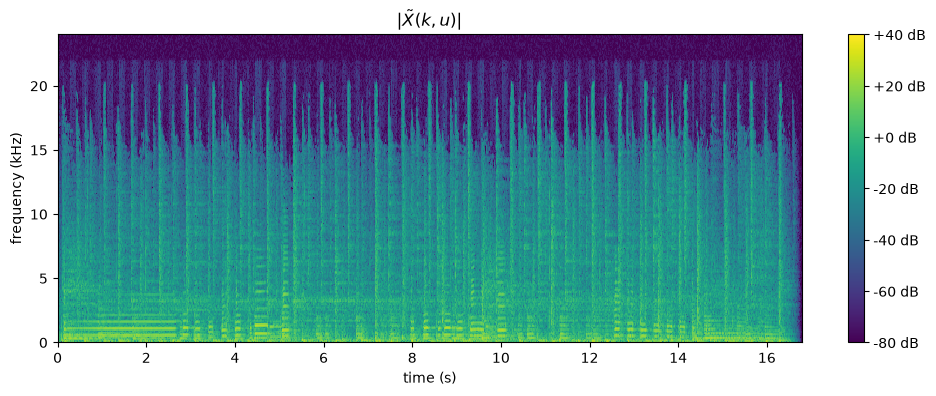

In [23]:
def istft(X, ws, R, N):
    # Overlap-add resynthesis: y(n) = sum_u y_s(u, n - uR), y_s(u, .) = IDFT[X(., u)] * ws.
    Nw = len(ws)
    y = np.zeros(N)
    for u in range(X.shape[1]):
        ys = np.real(np.fft.ifft(X[:, u]))[:Nw] * ws
        y[u * R:u * R + Nw] += ys
    return y


M = 512                                   # DFT order (M >= Nw)
w = ws = h_hann
X = stft(x, w, R, M)
y = istft(X, ws, R, len(x))

Nt = X.shape[1]
valid = slice(Nw - R, (Nt - 1) * R + R)  # samples covered by Nw/R = 4 frames
print(f'{Nt} frames, max |x - y| on the fully covered samples = {np.max(np.abs(x[valid] - y[valid])):.1e}')

L_ch = M // 2 + 1                         # channels 0..M/2 (nu >= 0)
plt.figure(figsize=(12, 4))
plt.imshow(20 * np.log10(np.abs(X[:L_ch]) + 1e-12), aspect='auto', interpolation='none', origin='lower',
           extent=[0, ((Nt - 1) * R + Nw) / Fs_in, 0, Fs_in / 2e3], vmin=-80, vmax=40)
plt.colorbar(format='%+2.0f dB')
plt.xlabel('time (s)'); plt.ylabel('frequency (kHz)'); plt.title(r'$|\tilde X(k, u)|$')
plt.show()

The reconstruction is perfect up to rounding errors.

### 2.3 STFT audio equalizer

#### Q7. Equalizer with $M/2 + 1$ real channels

Each frame is modified by $\tilde Y(k, u) = w_k\, \tilde X(k, u)$. The gains are chosen for $k = 0, \dots, M/2$ and copied to the negative frequencies ($w_{M-k} = w_k$), so that $\tilde Y(\cdot, u)$ keeps the Hermitian symmetry and $y$ stays real. This gives $M/2 + 1$ independent real channels, spaced by $F_s/M = 93.75$ Hz.

In [24]:
def equalizer(x, gains, w, ws, R, M):
    # STFT equalizer: gains w_k, k = 0..M/2, applied symmetrically to the channels k and M - k.
    gains_full = np.concatenate([gains, gains[-2:0:-1]])      # w_{M-k} = w_k
    X = stft(x, w, R, M)
    return istft(gains_full[:, np.newaxis] * X, ws, R, len(x))


f_ch = np.arange(M // 2 + 1) * Fs_in / M                     # centre frequencies of the channels

# 1) all gains equal to 1: perfect reconstruction
y_eq = equalizer(x, np.ones(M // 2 + 1), w, ws, R, M)
print(f'w_k = 1: max |x - y| = {np.max(np.abs(x[valid] - y_eq[valid])):.1e}')

# 2) "telephone" band-pass: keep 300 Hz - 3.4 kHz
gains_tel = ((f_ch >= 300) & (f_ch <= 3400)).astype(float)

# 3) smooth equalization curve (dB), interpolated on a log-frequency axis
f_nodes = [50, 100, 250, 1000, 3000, 8000, 16000]
g_nodes = [9, 9, 0, 0, -12, 0, 6]
gains_smooth = 10 ** (np.interp(np.log10(np.maximum(f_ch, 1)), np.log10(f_nodes), g_nodes) / 20)

examples = {'telephone': gains_tel, 'smooth EQ': gains_smooth}
outputs_eq = {name: equalizer(x, g, w, ws, R, M) for name, g in examples.items()}

w_k = 1: max |x - y| = 3.3e-16


To check the equalizer, we compare the gains $|w_k|^2$ with the measured ratio of the output and input spectra (Welch).

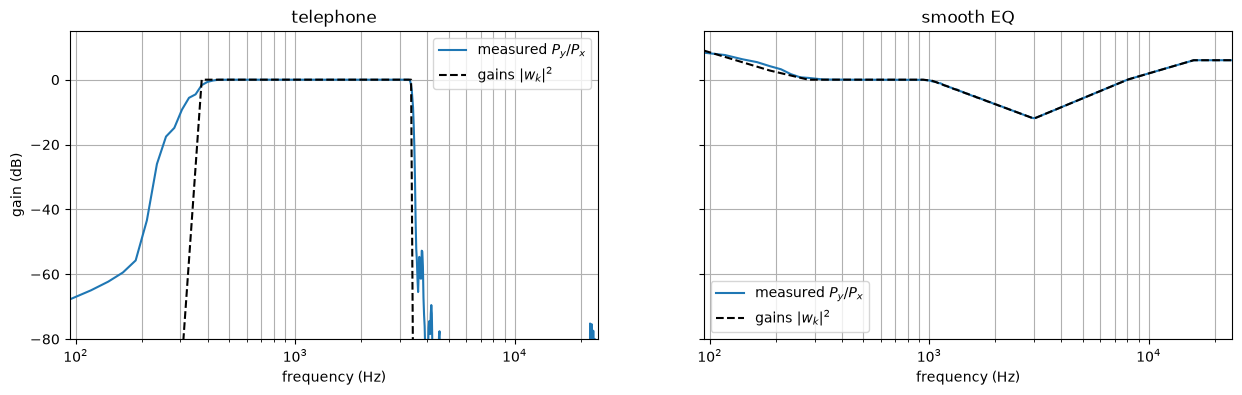

telephone


smooth EQ


In [25]:
f_w, P_in = ss.welch(x, Fs_in, nperseg=4 * M)
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, (name, g) in zip(axes, examples.items()):
    _, P_out = ss.welch(outputs_eq[name], Fs_in, nperseg=4 * M)
    ax.semilogx(f_w[1:], 10 * np.log10(P_out[1:] / P_in[1:]), label='measured $P_y / P_x$')
    ax.semilogx(f_ch[1:], 20 * np.log10(g[1:] + 1e-6), 'k--', label='gains $|w_k|^2$')
    ax.set(title=name, xlabel='frequency (Hz)', ylim=(-80, 15), xlim=(f_ch[1], Fs_in / 2))
    ax.legend(); ax.grid(True, which='both')
axes[0].set_ylabel('gain (dB)')
plt.show()

display(Audio(x[:excerpt * Fs_in], rate=Fs_in))
for name, y_k in outputs_eq.items():
    print(name)
    display(Audio(y_k[:excerpt * Fs_in], rate=Fs_in))

The measured response follows the gains. The sharp edges of the "telephone" mask are smoothed over about $\pm 2$ channels ($\approx 200$ Hz), but the stop-band still reaches more than 60 dB of attenuation. Multiplying the DFT by $ amounts to a circular convolution of each frame by the inverse DFT of the gains; the analysis and synthesis windows smooth the resulting frequency response over their main lobe (/N_w$, i.e. 4 channels here since  = N_w$). A sharp mask has a long impulse response, which wraps around the frame (time aliasing) and is only partly attenuated by $. Smooth gains have a short impulse response, so the equalizer then behaves almost exactly like an LTI filter with frequency response $ at $\nu = k/M$.